In [1]:
import pandas as pd

file_path = '/home/mohnish/amazon_sentiment_analysis/data/Cleaned_Amazon_Reviews_Sample.csv'
df = pd.read_csv(file_path)
print(f"Dataset Shape: {df.shape}")

Dataset Shape: (91939, 9)


/tmp/ipykernel_218507/3456913884.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Sentiment', data=df, palette='viridis')


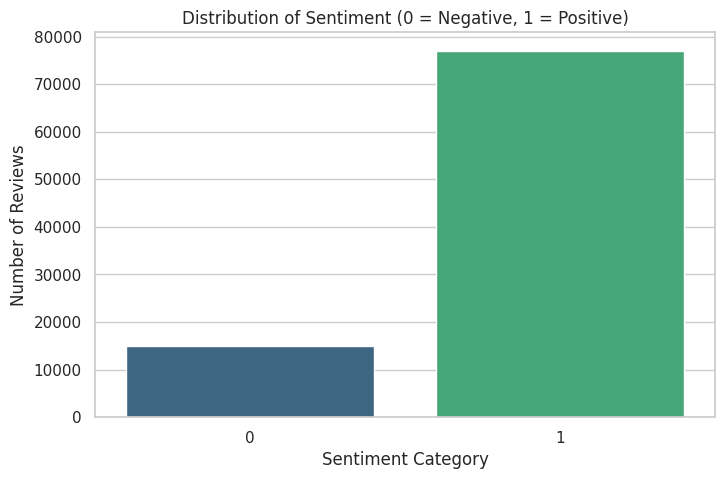

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

plt.figure(figsize=(8, 5))
sns.countplot(x='Sentiment', data=df, palette='viridis')
plt.title('Distribution of Sentiment (0 = Negative, 1 = Positive)')
plt.xlabel('Sentiment Category')
plt.ylabel('Number of Reviews')
plt.show()

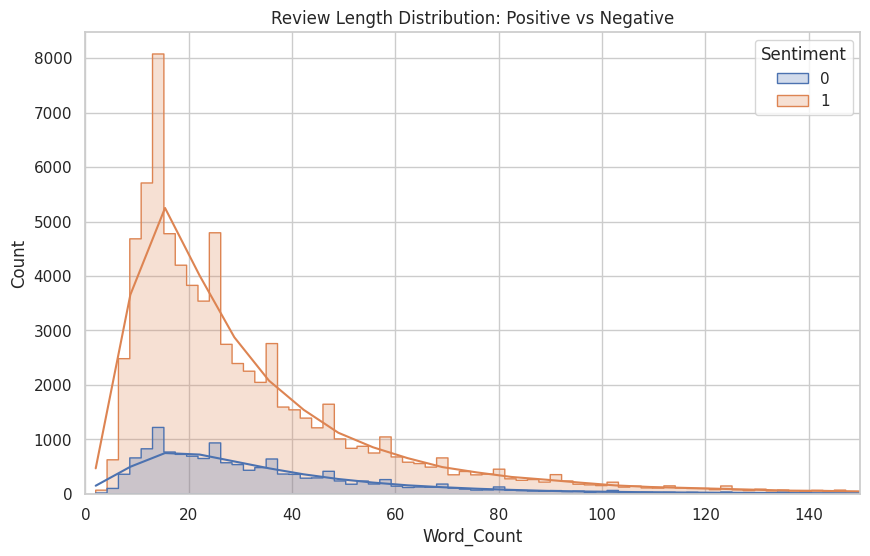

In [3]:
df['Word_Count'] = df['Final_Clean_Text'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Word_Count', hue='Sentiment', kde=True, element="step")
plt.title('Review Length Distribution: Positive vs Negative')
plt.xlim(0, 150) 
plt.show()

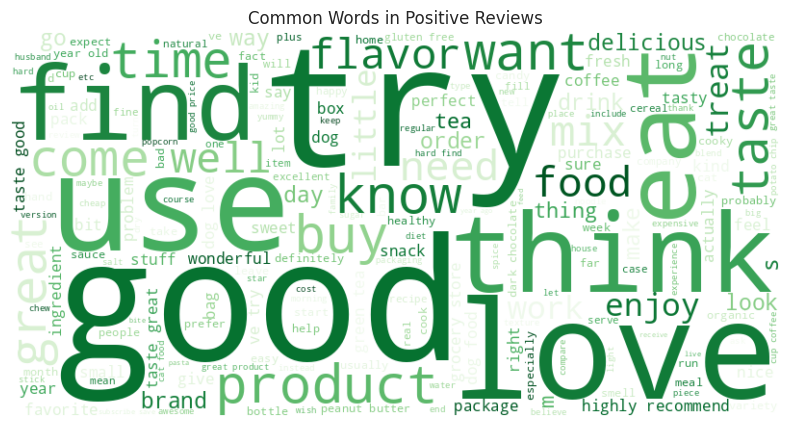

In [4]:
from wordcloud import WordCloud

pos_text = " ".join(df[df['Sentiment'] == 1]['Final_Clean_Text'])
neg_text = " ".join(df[df['Sentiment'] == 0]['Final_Clean_Text'])

wordcloud_pos = WordCloud(width=800, height=400, background_color='white', colormap='Greens').generate(pos_text)
wordcloud_neg = WordCloud(width=800, height=400, background_color='white', colormap='Reds').generate(neg_text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_pos, interpolation='bilinear')
plt.title('Common Words in Positive Reviews')
plt.axis('off')
plt.show()

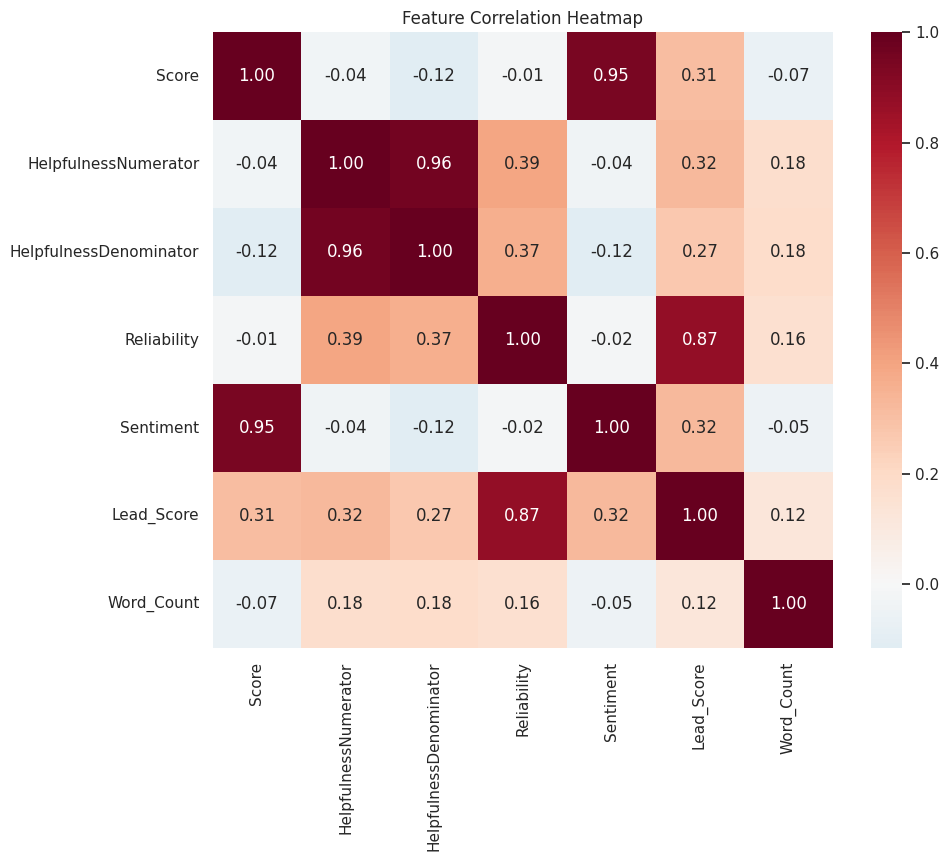

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_df = df[['Score', 'HelpfulnessNumerator', 'HelpfulnessDenominator', 'Reliability', 'Sentiment', 'Lead_Score', 'Word_Count']]

corr_matrix = numeric_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()